In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../dataset/ai4i2020.csv")

In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [6]:
df.nunique()

UDI                        10000
Product ID                 10000
Type                           3
Air temperature [K]           93
Process temperature [K]       82
Rotational speed [rpm]       941
Torque [Nm]                  577
Tool wear [min]              246
Machine failure                2
TWF                            2
HDF                            2
PWF                            2
OSF                            2
RNF                            2
dtype: int64

In [7]:
df.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [8]:
df = df.drop(columns=['UDI'])

In [9]:
corr_matrix = df.corr(numeric_only=True)

<Axes: >

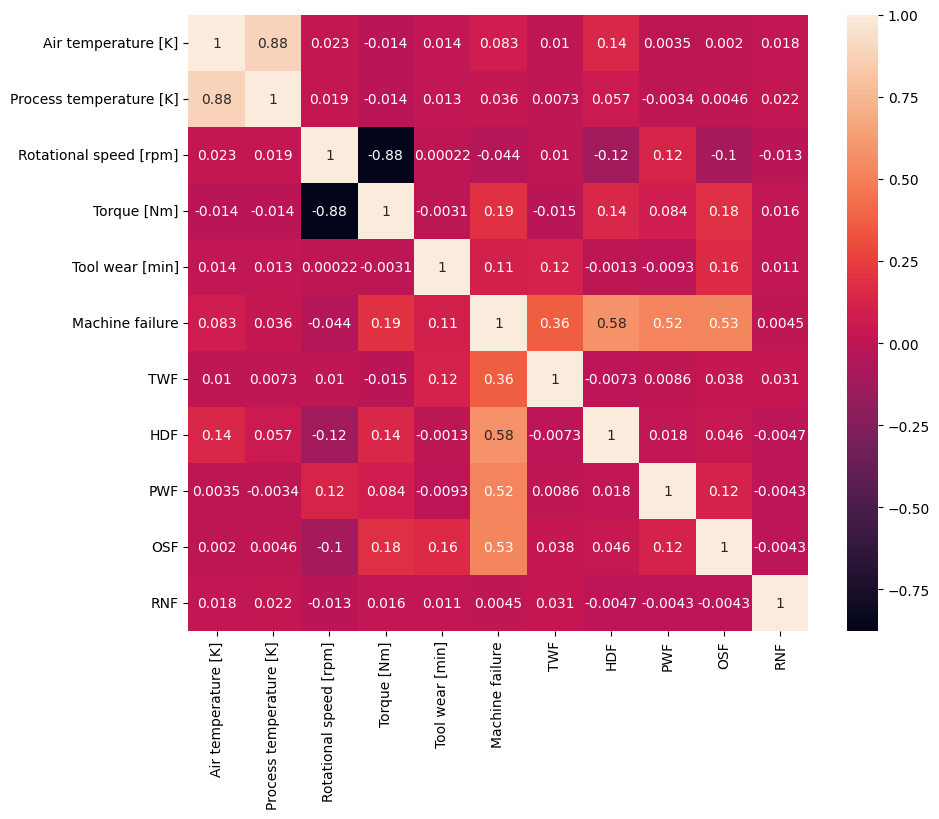

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True)

### "TWF, HDF, PWF, OSF, and RNF represent specific failure mechanisms. Since Machine failure is derived from these failure modes, using them as input features would introduce target leakage. Therefore, they were excluded from model training and used only for exploratory analysis."

In [11]:
df.columns

Index(['Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='str')

In [12]:
df = df[['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure']]

In [13]:
pd.crosstab(df['Type'], df['Machine failure'])

Machine failure,0,1
Type,,
H,982,21
L,5765,235
M,2914,83


In [14]:
pd.crosstab(df['Type'], df['Machine failure'], normalize='index')*100

Machine failure,0,1
Type,,
H,97.906281,2.093719
L,96.083333,3.916667
M,97.230564,2.769436


In [15]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [16]:
df['Machine failure'].value_counts(normalize=True)*100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

### Type vs Failure

<Axes: xlabel='Type', ylabel='count'>

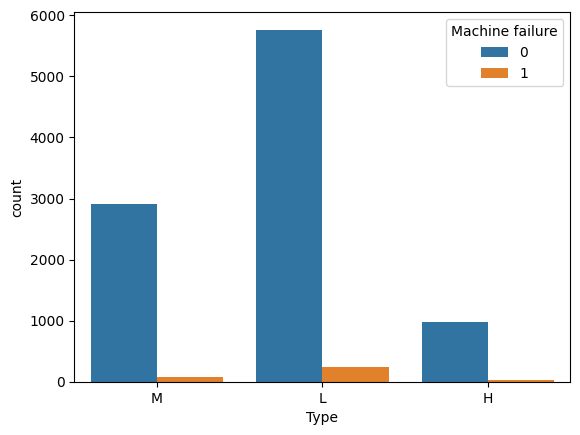

In [17]:
sns.countplot(data=df, x='Type', hue='Machine failure')

In [18]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


<Axes: xlabel='Type', ylabel='count'>

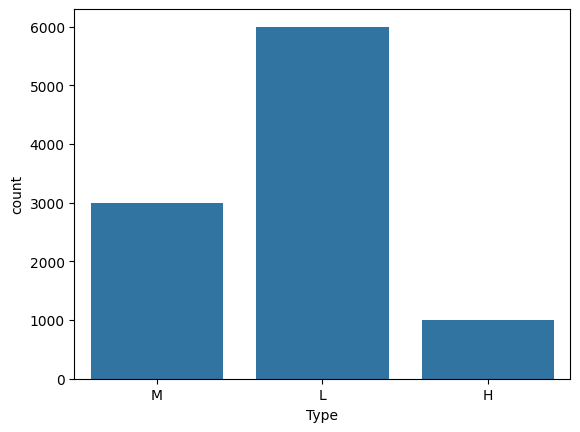

In [19]:
sns.countplot(x='Type', data=df)

<Axes: xlabel='Torque [Nm]', ylabel='Tool wear [min]'>

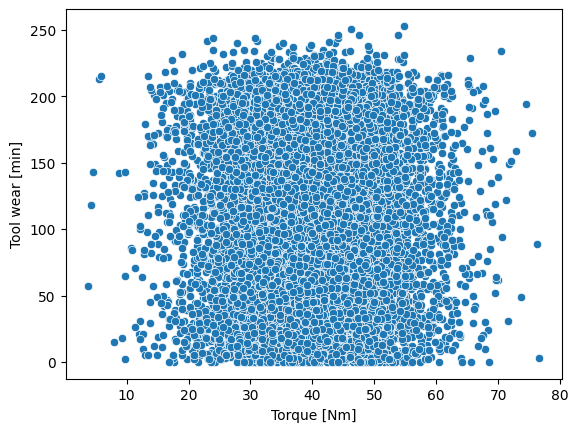

In [20]:
sns.scatterplot(
    x='Torque [Nm]',
    y='Tool wear [min]',
    data=df
)

<Axes: >

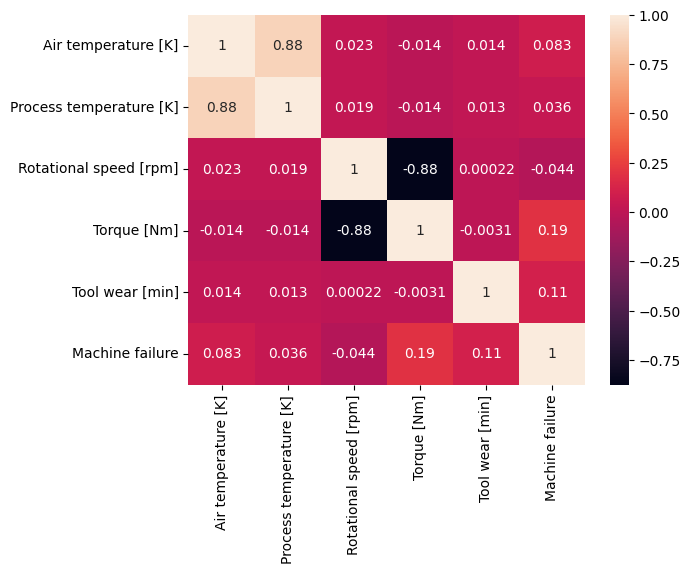

In [21]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

<Axes: xlabel='Machine failure', ylabel='Torque [Nm]'>

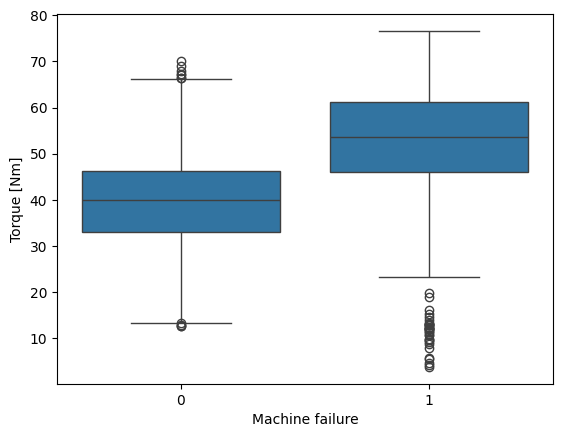

In [22]:
sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df)

In [23]:
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure'],
      dtype='str')

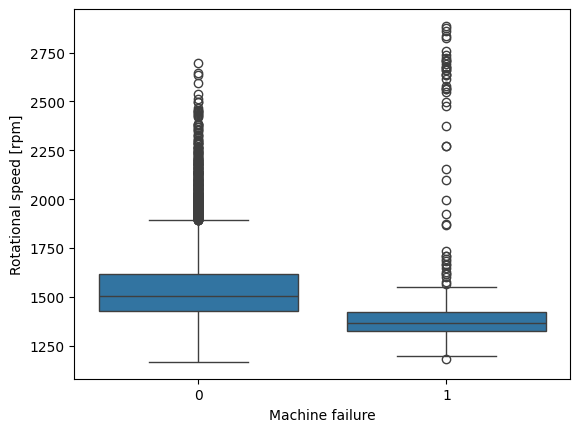

In [24]:
sns.boxplot(
    x='Machine failure',
    y='Rotational speed [rpm]',
    data=df
)
plt.show()

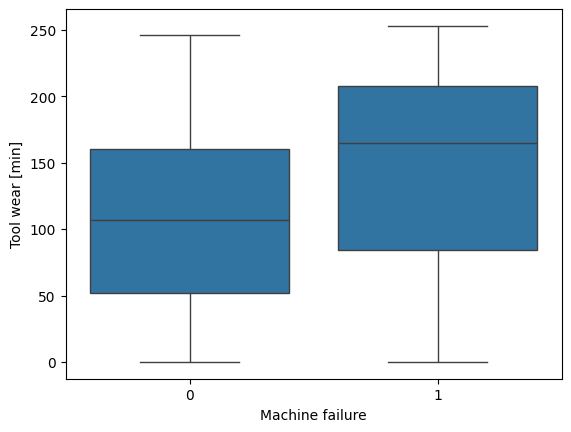

In [25]:
sns.boxplot(
    x= 'Machine failure',
    y='Tool wear [min]',
    data=df
)
plt.show()

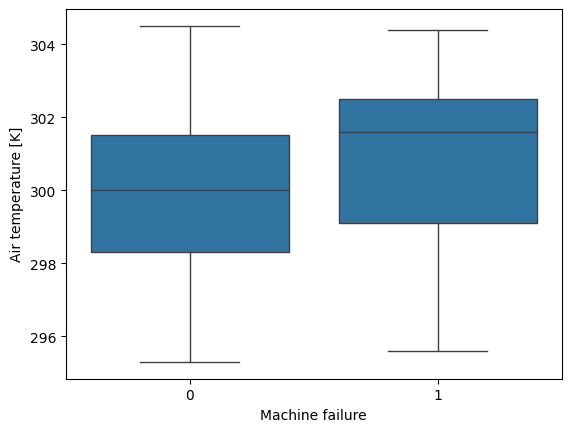

In [26]:
sns.boxplot(
    x='Machine failure',
    y='Air temperature [K]',
    data=df
)
plt.show()

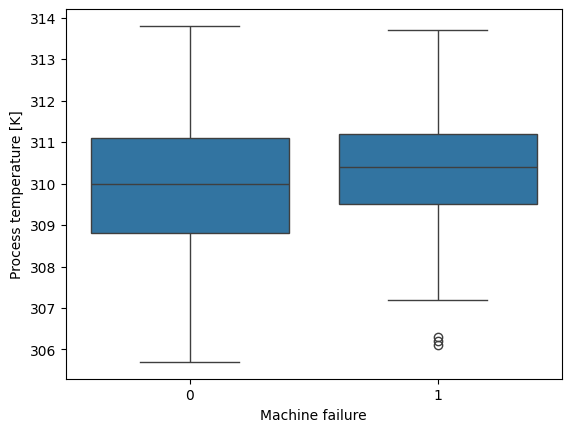

In [27]:
sns.boxplot(
    x='Machine failure',
    y='Process temperature [K]',
    data=df
)
plt.show()

In [30]:
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure'],
      dtype='str')

In [ ]:
sns.barplot(x='Torque [Nm]', )